# BED-1304 Python Lab

## Øving 6 – Datavisualisering med Matplotlib

**Løsningsforslag**  
**Forfatter:** Markus J. Aase

---

I denne notebooken løser vi alle oppgavene i Øving 6. I tillegg viser notebooken noen enkle grep som gjør figurer mer lesbare og besvarelsen mer gjennomarbeidet.

### Hovedidé
En god visualisering bør gjøre det lett å forstå:

1. **Hva** som vises
2. **Hvilke enheter** aksene bruker
3. **Hva hovedmønsteret er**
4. Om det finnes **avvik eller ekstremverdier**

Vi bruker derfor tydelige titler, akseetiketter, passende figurstørrelse og korte kommentarer til grafene.


## Importer biblioteker

Vi importerer bibliotekene én gang øverst i notebooken.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

## Oppgave 1 – Ditt første linjeplot

Vi har salgsinntekter for fem dager:

```python
dager = [1, 2, 3, 4, 5]
inntekt = [1500, 2300, 1800, 3100, 2800]
```

Et linjeplot passer når vi vil vise hvordan en verdi utvikler seg over en ordnet akse, for eksempel tid.


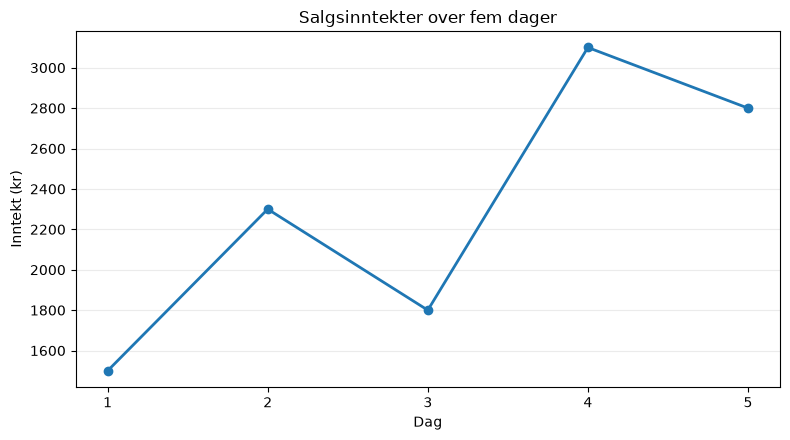

In [2]:
# Data
dager = [1, 2, 3, 4, 5]
inntekt = [1500, 2300, 1800, 3100, 2800]

# Lager figur og akse
fig, ax = plt.subplots(figsize=(8, 4.5))

# Linjeplot med markører på observasjonene
ax.plot(dager, inntekt, marker="o", linewidth=2)

# Tittel og akseetiketter gjør grafen selvforklarende
ax.set_title("Salgsinntekter over fem dager")
ax.set_xlabel("Dag")
ax.set_ylabel("Inntekt (kr)")

# Viser alle dagene som egne verdier på x-aksen
ax.set_xticks(dager)

# Et svakt rutenett gjør verdier lettere å lese av
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


**Tips:** `figsize`, tydelige etiketter og `plt.tight_layout()` er små grep som ofte gjør figuren betydelig bedre. Unngå å legge til elementer som ikke hjelper leseren.


## Oppgave 2 – Kvartalsomsetning

Et stolpediagram passer godt når vi sammenligner størrelsen på separate kategorier.


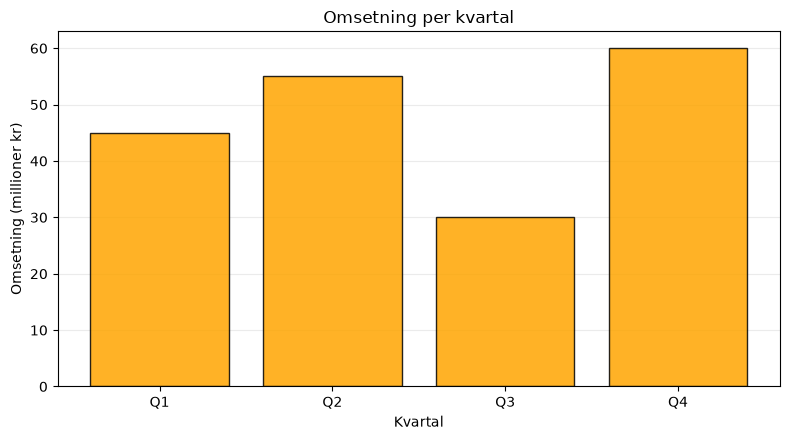

In [3]:
# Data
kvartaler = ["Q1", "Q2", "Q3", "Q4"]
omsetning = [45, 55, 30, 60]

fig, ax = plt.subplots(figsize=(8, 4.5))

# Stolpediagram
ax.bar(kvartaler, omsetning, color="orange", edgecolor="black", alpha=0.85)

ax.set_title("Omsetning per kvartal")
ax.set_xlabel("Kvartal")
ax.set_ylabel("Omsetning (millioner kr)")

# Rutenett kun på y-aksen gir hjelp til avlesning uten å gjøre figuren rotete
ax.grid(axis="y", alpha=0.25)

# Sørger for at rutenettet ligger bak stolpene
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


**Hva kjennetegner en god besvarelse her?**

- Stolpediagram er et naturlig valg for fire kategorier.
- Y-aksen oppgir enhet: *millioner kr*.
- Tittelen beskriver hva figuren viser.
- Rutenettet hjelper avlesning, men dominerer ikke grafen.


## Oppgave 3 – Lese inn bilpark-data fra GitHub

Vi leser datasettet direkte fra kurs-GitHuben.

Notebooken sjekker først om `bilparken_ssb.csv` ligger lokalt. Hvis ikke, brukes Raw-lenken fra GitHub. Dette gjør koden litt mer robust dersom man arbeider uten nett.


In [4]:
# Raw-lenke til datasettet på GitHub
url = "https://raw.githubusercontent.com/uit-bed-1304-h26/uit-bed-1304-h26.github.io/main/data/bilparken_ssb.csv"

# Dersom filen allerede finnes lokalt, bruker vi den.
# Ellers leser vi direkte fra GitHub.
lokal_fil = Path("bilparken_ssb.csv")

# Her kan du laste inn slik vi gjorde i forelesning
# Last ned filen lokalt, og finn den stien. Begge funker.

if lokal_fil.exists():
    df = pd.read_csv(lokal_fil)
else:
    df = pd.read_csv(url)

# Viser de fem første radene
df.head()


,Tid,Bilmerker,12 - 15 år,16 - 20 år,4 - 7 år,8 - 11 år,Over 20 år,Under 4 år,Gjennomsnittsalder ved vraking (år),Personbilbestand 31. desember,Personbiler vraket mot pant,Personbiler vraket mot pant (prosent av bestanden)
0,2021,Audi,30096,23230,27302,35723,12423,29778,19.2,158552.0,6390.0,4.0
1,2021,Bmw,33358,21524,33096,41841,13210,21429,18.7,164458.0,4104.0,2.5
2,2021,Bmw i,0,0,15935,207,0,9501,3.4,25643.0,41.0,0.2
3,2021,Chevrolet,1437,2666,449,1236,13639,64,21.9,19491.0,567.0,2.9
4,2021,Citroen,7839,4426,7424,11999,2218,5080,16.2,38986.0,2531.0,6.5


**Ekstra kontroll:** Det er ofte lurt å undersøke datasettet før man begynner å plotte. For eksempel:


In [5]:
print("Dimensjon:", df.shape)
print("\nKolonner:")
print(df.columns.tolist())


Dimensjon: (24, 12)

Kolonner:
['Tid', 'Bilmerker', '12 - 15 år', '16 - 20 år', '4 - 7 år', '8 - 11 år', 'Over 20 år', 'Under 4 år', 'Gjennomsnittsalder ved vraking (år)', 'Personbilbestand 31. desember', 'Personbiler vraket mot pant', 'Personbiler vraket mot pant (prosent av bestanden)']


## Oppgave 4 – Visualisere personbilbestanden

Vi bruker de 10 første radene og sammenligner personbilbestanden mellom bilmerkene.


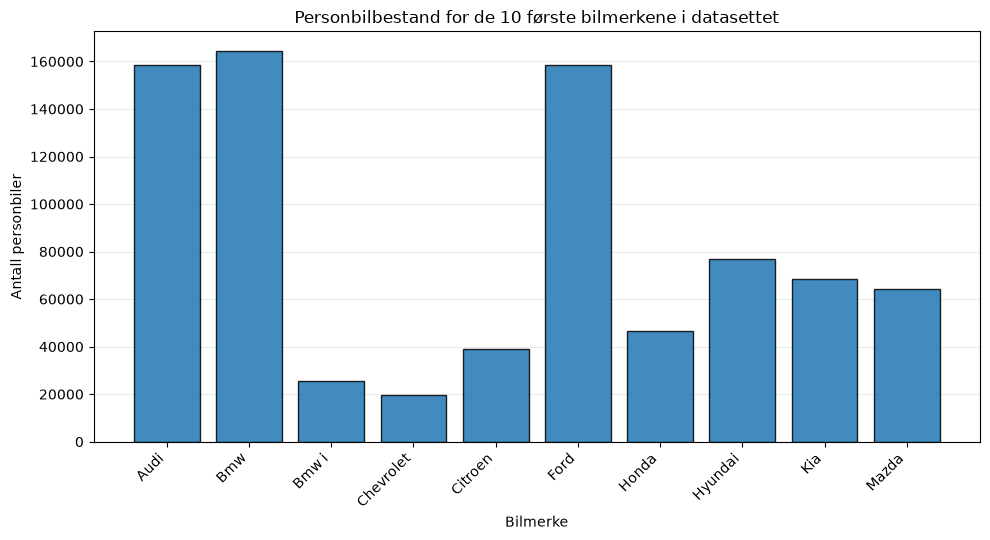

In [5]:
# Velger de 10 første radene
df_ti = df.head(10)

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.bar(
    df_ti["Bilmerker"],
    df_ti["Personbilbestand 31. desember"],
    edgecolor="black",
    alpha=0.85
)

ax.set_title("Personbilbestand for de 10 første bilmerkene i datasettet")
ax.set_xlabel("Bilmerke")
ax.set_ylabel("Antall personbiler")

# Bilmerkenavnene trenger mer plass enn vanlige tall
plt.xticks(rotation=45, ha="right")

ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


**Tips:** Lange kategorinavn er en vanlig årsak til uleselige figurer. `rotation=45`, `ha="right"` og `tight_layout()` løser ofte problemet uten at man trenger å gjøre figuren komplisert.


## Oppgave 5 – Sammenheng mellom alder ved vraking og panteprosent

Et scatterplot brukes når vi vil undersøke sammenhengen mellom to numeriske variabler.

Hvert punkt representerer ett bilmerke.


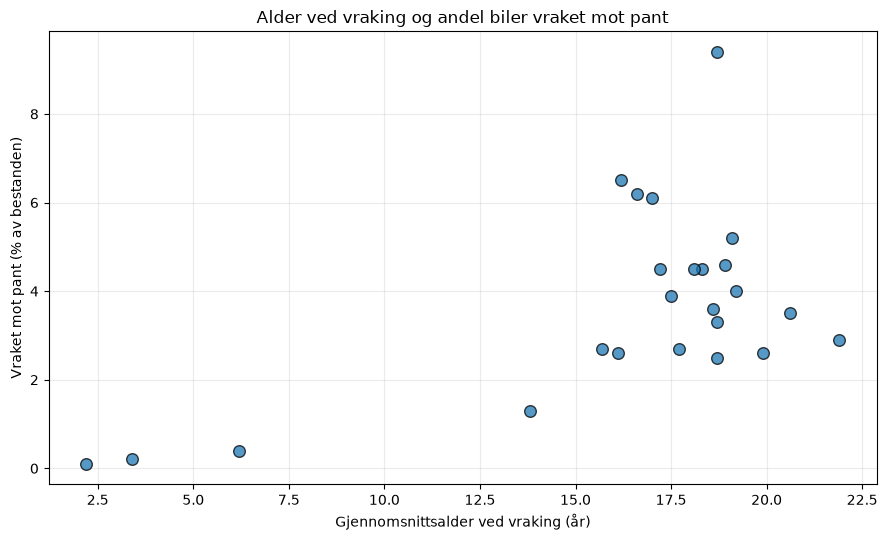

In [6]:
# Variablene vi ønsker å sammenligne
x = df["Gjennomsnittsalder ved vraking (år)"]
y = df["Personbiler vraket mot pant (prosent av bestanden)"]

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.scatter(
    x,
    y,
    s=70,
    alpha=0.75,
    edgecolor="black"
)

ax.set_title("Alder ved vraking og andel biler vraket mot pant")
ax.set_xlabel("Gjennomsnittsalder ved vraking (år)")
ax.set_ylabel("Vraket mot pant (% av bestanden)")

ax.grid(alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Kommentar:
# De fleste bilmerkene ligger rundt 14–22 års vrakealder, mens enkelte
# elbilmerker har svært lav gjennomsnittsalder. Opel skiller seg samtidig
# ut med en klart høyere panteprosent enn de fleste andre merkene.


### Ekstra: merk noen interessante observasjoner

Dette er ikke nødvendig for å løse oppgaven, men etiketter kan være nyttige når vi ønsker å forklare ekstremverdier.


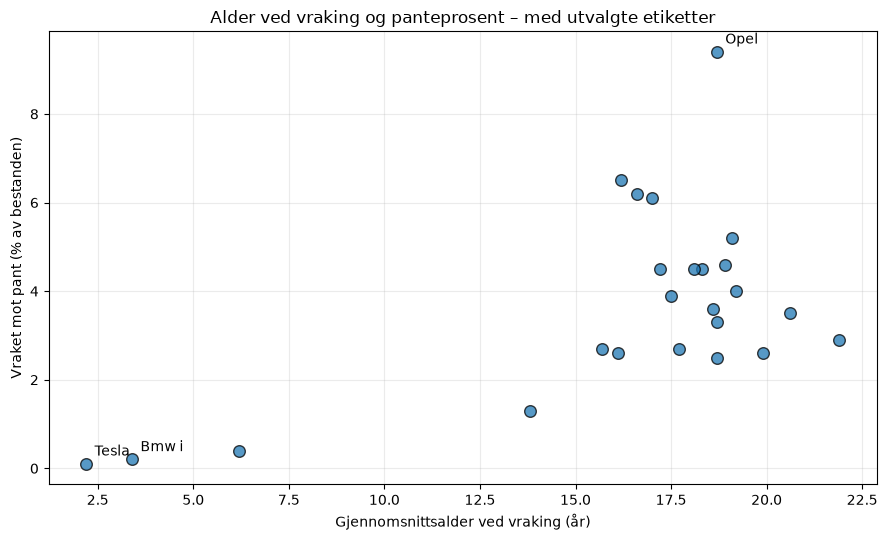

In [7]:
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.scatter(
    df["Gjennomsnittsalder ved vraking (år)"],
    df["Personbiler vraket mot pant (prosent av bestanden)"],
    s=70,
    alpha=0.75,
    edgecolor="black"
)

# Merker noen observasjoner som skiller seg ut
for bilmerke in ["Bmw i", "Tesla", "Opel"]:
    rad = df[df["Bilmerker"] == bilmerke]

    ax.annotate(
        bilmerke,
        (
            rad["Gjennomsnittsalder ved vraking (år)"].iloc[0],
            rad["Personbiler vraket mot pant (prosent av bestanden)"].iloc[0]
        ),
        xytext=(6, 6),
        textcoords="offset points"
    )

ax.set_title("Alder ved vraking og panteprosent – med utvalgte etiketter")
ax.set_xlabel("Gjennomsnittsalder ved vraking (år)")
ax.set_ylabel("Vraket mot pant (% av bestanden)")
ax.grid(alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


---

# Hva kjennetegner en god besvarelse?

En god besvarelse trenger ikke å være avansert. Den bør først og fremst være **korrekt, ryddig og lett å forstå**.

### 1. Koden kan kjøres fra topp til bunn
Alle variabler må være definert før de brukes, og cellene bør ligge i en naturlig rekkefølge.

### 2. Riktig graftype brukes
- **Linjeplot:** utvikling over tid eller annen ordnet akse
- **Stolpediagram:** sammenligning av kategorier
- **Scatterplot:** sammenheng mellom to numeriske variabler

### 3. Grafen er selvforklarende
En leser bør forstå figuren uten å studere koden. Bruk derfor:

- Beskrivende tittel
- Navn på begge aksene
- Enheter der det er relevant

### 4. Figuren er lesbar
Pass på at:

- Tekst ikke overlapper
- Figuren er stor nok
- Rutenett brukes moderat
- Farger og visuelle effekter ikke tar oppmerksomheten bort fra dataene

### 5. Koden kommenteres fornuftig
Kommentarer bør forklare **hvorfor** eller **hva et kodeavsnitt gjør**, ikke bare gjenta selve Python-koden.

God kommentar:

```python
# Roterer bilmerkenavnene slik at de ikke overlapper
plt.xticks(rotation=45)
```

Mindre nyttig kommentar:

```python
# Setter rotation lik 45
plt.xticks(rotation=45)
```

### 6. Grafen tolkes kort
Når oppgaven spør om mønster eller ekstremverdier, holder det ofte med én presis setning. Beskriv det du faktisk kan se i figuren, og unngå å trekke sterkere konklusjoner enn dataene støtter.


## Kort oppsummering

I denne øvingen har vi brukt:

- `plt.plot()` til linjeplot
- `plt.bar()` til stolpediagram
- `plt.scatter()` til spredningsplot
- `pd.read_csv()` til å hente data
- Pandas til å velge observasjoner og kolonner
- Matplotlib til å lage tydelige, lesbare figurer

Et godt plot handler ikke om flest mulig effekter. Målet er å presentere dataene så tydelig som mulig.
